# **Pupil Detection**

**Authors:** Katrine Bjerre (katbj@itu.dk) & Kristine Emilie Risager Pedersen (krep@itu.dk)

Last edited: 15.03.2026

## **Table of Contents**

1. [Setup](#setup)
   - [Imports](#imports)
   - [Data path](#data-path)
   - [Save screen coordinates (normalized + pixels)](#save-screen-coordinates-normalized-+-pixels)
2. [Pupil Detection](#pupil-detection)
   - [Subject specific configuration](#subject-specific-configuration)
   - [Running pupil detection for all subjects](#running-pupil-detection-for-all-subjects)
3. [Data Filtering](#data-filtering)
   - [Compute mean pupil coordinates and filter invalid subjects](#compute-mean-pupil-coordinates-and-filter-invalid-subjects)
   - [Collect images to exclude (bad subjects + failed detections)](#collect-images-to-exclude-bad-subjects--failed-detections)
   - [Combine automatic and manual bad image filters](#combine-automatic-and-manual-bad-image-filters)
4. [Quality control and visualization](#quality-control-and-visualization)

<br/>

## **Setup**

### Imports

In [12]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import iml_util
import filtering_util
import importlib


importlib.reload(iml_util)
importlib.reload(filtering_util)

<module 'filtering_util' from '/Users/kristinerisager/Documents/GitHub/Thesis2026/Preprocessing/pupil_detection/filtering_util.py'>

### Data path 

In [13]:
ROOT_DIR = Path("../..").resolve()
DATA_DIR = ROOT_DIR / "data"
PUPIL_DETECTION_DIR = ROOT_DIR / "Preprocessing" / "pupil_detection"

data_dir = DATA_DIR

### Save screen coordinates (normalized + pixels)

In [ ]:
xs = np.linspace(0.15, 0.85, 5)
ys = np.linspace(0.15, 0.85, 5)

def get_norm_coord(target_id):
    """Return normalized (x, y) for a target on a 5x5 grid."""
    if not 0 <= target_id <= 24:
        raise ValueError("target_id must be between 0 and 24")

    row = target_id // 5
    col = target_id % 5
    return xs[col], ys[row]

def get_pixel_coord(target_id, W=1440, H=900):
    """Convert target ID to pixel (x, y) coordinates."""
    rel_x, rel_y = get_norm_coord(target_id)
    return int(rel_x * W), int(rel_y * H)

SCREEN_COORDS_NORM = np.array([get_norm_coord(i) for i in range(25)])
SCREEN_COORDS_PIXELS = np.array([get_pixel_coord(i, W=1440, H=900) for i in range(25)])

# Save normalized coordinates
pd.DataFrame(SCREEN_COORDS_NORM, columns=["rel_x", "rel_y"]).to_csv(
    "screen_coordinates.csv",
    index=False,
    header=False
)

# Save pixel coordinates
pd.DataFrame(SCREEN_COORDS_PIXELS, columns=["x_px", "y_px"]).to_csv(
    "screen_coordinates_pixels.csv",
    index=False,
    header=False
)

print("Saved screen_coordinates.csv")
print("Saved screen_coordinates_pixels.csv")
print("\nNormalized:")
print(SCREEN_COORDS_NORM[:5])
print("\nPixels:")
print(SCREEN_COORDS_PIXELS[:5])

Saved screen_coordinates.csv
Saved screen_coordinates_pixels.csv

Normalized:
[[0.15  0.15 ]
 [0.325 0.15 ]
 [0.5   0.15 ]
 [0.675 0.15 ]
 [0.85  0.15 ]]

Pixels:
[[ 216  135]
 [ 467  135]
 [ 720  135]
 [ 971  135]
 [1224  135]]


<br/>

## **Pupil Detection**

In [24]:
def pupil_detection(img, threshold_value, debug, x_top, y_top, x_bot, y_bot, max_axis_ratio=2
):
    """
    Returns (x, y) in original image coordinates, or None.
    Skips frames if no fitted ellipse passes axis-size and axis-ratio checks.
    """

    cv = iml_util.cv

    # --- 0) Crop ROI ---
    x1, y1 = x_top, y_top
    x2, y2 = x_bot, y_bot

    roi = img[y1:y2, x1:x2].copy()
    roi_color = cv.cvtColor(roi, cv.COLOR_GRAY2BGR)

    if debug:
        dbg_full = cv.cvtColor(img.copy(), cv.COLOR_GRAY2BGR)
        cv.rectangle(dbg_full, (x1, y1), (x2, y2), (0, 255, 0), 2)
        iml_util.show_image("Bounding Box", dbg_full)
        iml_util.show_image("ROI (cropped)", roi)

    # --- 1) Threshold -> 2) Edges -> 3) Contours ---
    _, thresh = cv.threshold(roi, threshold_value, 255, cv.THRESH_BINARY)
    edges = cv.Canny(thresh, 100, 200)
    contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    if debug:
        roi_cnt = roi_color.copy()
        cv.drawContours(roi_cnt, contours, -1, (255, 0, 0), 1)
        iml_util.show_image("ROI Contours", roi_cnt)
        iml_util.show_image("ROI Threshold", thresh)
        iml_util.show_image("ROI Edges", edges)

    # --- 4) Evaluate contours ---
    valid = None
    for c in sorted(contours, key=len, reverse=True):

        if len(c) < 5:
            continue

        ellipse = cv.fitEllipse(c)
        (cx, cy), (a1, a2), ang = ellipse
        major, minor = (max(a1, a2), max(1e-6, min(a1, a2)))
        ratio = major / minor

        if debug:
            print(f"[CAND] pts={len(c)} minor={minor:.2f} major={major:.2f} ratio={ratio:.2f}")

        if ratio > max_axis_ratio:
            continue

        valid = (ellipse, (cx, cy), major, minor, ratio)
        break

    if valid is None:
        if debug:
            print("[SKIP] No contour passed size/ratio checks.")
        return None

    ellipse, (cx, cy), major, minor, ratio = valid
    center = (cx + x1, cy + y1)

    if debug:
        roi_draw = roi_color.copy()
        cv.ellipse(roi_draw, ellipse, (255, 255, 255), 2)
        cv.circle(roi_draw, (int(cx), int(cy)), 4, (0, 0, 255), -1)
        iml_util.show_image("ROI: Chosen ellipse", roi_draw)

        full_draw = cv.cvtColor(img.copy(), cv.COLOR_GRAY2BGR)
        cv.circle(full_draw, (int(center[0]), int(center[1])), 5, (0, 0, 255), -1)
        iml_util.show_image("Full image: Pupil center", full_draw)

    return center if center != (0, 0) else None

In [ ]:
def process_frames(output_directory, frames_folder, threshold_value, debug,
                   x_top, y_top, x_bottom, y_bottom):
    """Detect pupil centers and save pupil_coordinates.csv."""

    eye_images = iml_util.load_images_from_folder(frames_folder)

    centers = []
    data = []
    valid_images = []
    valid_centers = []
    invalid_images = []

    for image_file, img in eye_images:
        img = iml_util.split_img(img)

        center = pupil_detection(
            img,
            threshold_value,
            debug,
            x_top, y_top, x_bottom, y_bottom
        )

        if center is not None:
            centers.append(center)
            valid_images.append((image_file, img))
            valid_centers.append(center)
            data.append({"image": image_file, "px": center[0], "py": center[1]})
        else:
            centers.append(None)
            invalid_images.append((image_file, img))

    df = iml_util.pd.DataFrame(data)
    out_csv = iml_util.os.path.join(output_directory, "pupil_coordinates.csv")
    df.to_csv(out_csv, index=False)

    if debug and len(invalid_images) > 0:
        iml_util.create_image_grid(
            invalid_images,
            [None] * len(invalid_images),
            output_directory,
            grid_name="invalid_pupil_centers_grid",
            max_images=100
        )

    print(f"Total frames processed: {len(eye_images)}")
    print(f"Number of detected centers: {len([c for c in centers if c is not None])}")
    print(f"Pupil coordinates saved to {out_csv}")

In [ ]:
def process_single_id(base_dir=DATA_DIR, subject_id="001",
                      threshold_value=42, debug=False,
                      x_top=210, y_top=235, x_bottom=460, y_bottom=360):
    """Process all frames for a single subject with given threshold and crop box."""

    folder = Path(base_dir) / subject_id
    frames_folder = folder / "frames"

    print(f"\n→ Processing {subject_id} (thr={threshold_value}, "
          f"box=({x_top},{y_top},{x_bottom},{y_bottom}), debug={debug})")

    if not folder.exists():
        raise FileNotFoundError(f"Subject folder not found: {folder}")

    if not frames_folder.exists():
        raise FileNotFoundError(f"Frames folder not found: {frames_folder}")

    process_frames(
        output_directory=str(folder),
        frames_folder=str(frames_folder),
        threshold_value=threshold_value,
        debug=debug,
        x_top=x_top,
        y_top=y_top,
        x_bottom=x_bottom,
        y_bottom=y_bottom
    )

    print(f"Finished {subject_id}")

### Subject specific configuration

In [ ]:
# Each tuple: (ID, threshold, x_top, y_top, x_bottom, y_bottom)
SUBJECT_CONFIG = [
    ("001", 35, 880, 400, 1450, 800),
    ("002", 40, 830, 330, 1450, 800),
    ("003", 40, 480, 150, 1300, 650),
    ("004", 25, 650, 315, 1300, 680),  # Mascara, lower threshold, small pupils
    ("005", 35, 700, 330, 1300, 700),  # Mascara, lower threshold
    ("006", 42, 880, 5, 1450, 400),    # Glasses, higher threshold
    ("007", 40, 600, 190, 1210, 590),  # Glasses, small pupils
    ("008", 55, 900, 180, 1400, 500),  # Eyeliner, thick glasses. 
    ("009", 35, 770, 200, 1430, 600),
    ("010", 40, 880, 190, 1460, 590),
    ("011", 40, 800, 150, 1450, 600),
    ("012", 40, 950, 270, 1600, 700),
    ("013", 40, 1000, 200, 1750, 600),  # Glasses, much reflection
    ("014", 40, 770, 380, 1450, 800),
    ("015", 32, 870, 170, 1550, 600),
    ("016", 32, 800, 330, 1450, 800),
    ("017", 35, 690, 170, 1220, 550),
    ("018", 40, 850, 20, 1450, 460),
    ("019", 30, 850, 330, 1450, 800),  # Mascara
    ("020", 38, 850, 300, 1480, 750),
    ("021", 40, 880, 330, 1400, 700),  # Mascara, glasses
    ("022", 40, 800, 330, 1400, 700),  # Mascara, glasses
    ("023", 32, 800, 100, 1400, 500),
    ("024", 32, 880, 300, 1450, 740),
    ("025", 32, 720, 240, 1400, 660),
    ("026", 32, 750, 250, 1400, 680),
    ("027", 35, 780, 300, 1400, 800),
    ("028", 32, 800, 200, 1600, 700),
    ("029", 35, 850, 190, 1600, 650),
    ("030", 35, 840, 300, 1600, 800),
    ("031", 35, 700, 270, 1400, 700),
    ("032", 35, 700, 220, 1500, 700),
    ("033", 35, 700, 240, 1500, 780),
    ("033", 35, 700, 240, 1500, 780),
    ("034", 35, 880, 130, 1600, 550),
    ("035", 25, 800, 160, 1500, 600),  # Heavy mascara
    ("036", 35, 720, 160, 1500, 600),
    ("037", 35, 750, 290, 1500, 750),
    ("038", 32, 650, 260, 1300, 720),
    ("039", 32, 650, 280, 1310, 720),
    ("040", 35, 650, 200, 1450, 700),
    ("041", 35, 650, 200, 1350, 700),
    ("042", 35, 570, 230, 1300, 700),
    ("043", 32, 700, 40, 1500, 450),
    ("044", 32, 520, 100, 1300, 550),
    ("045", 35, 550, 40, 1300, 500),
    ("046", 35, 530, 200, 1270, 700),   
]

### Running pupil detection for all subjects

In [30]:
for sid, thr, x1, y1, x2, y2 in SUBJECT_CONFIG:
    print(f"\nProcessing {sid} (thr={thr})")
    process_single_id(DATA_DIR, sid, thr, False, x1, y1, x2, y2)


Processing 001 (thr=35)

→ Processing 001 (thr=35, box=(880,400,1450,800), debug=False)
Total frames processed: 1595
Number of detected centers: 1595
Pupil coordinates saved to /Users/kristinerisager/Documents/GitHub/Thesis2026/data/001/pupil_coordinates.csv
Finished 001

Processing 002 (thr=40)

→ Processing 002 (thr=40, box=(830,330,1450,800), debug=False)
Total frames processed: 2435
Number of detected centers: 2416
Pupil coordinates saved to /Users/kristinerisager/Documents/GitHub/Thesis2026/data/002/pupil_coordinates.csv
Finished 002

Processing 003 (thr=40)

→ Processing 003 (thr=40, box=(480,150,1300,650), debug=False)
Total frames processed: 2437
Number of detected centers: 2378
Pupil coordinates saved to /Users/kristinerisager/Documents/GitHub/Thesis2026/data/003/pupil_coordinates.csv
Finished 003

Processing 004 (thr=25)

→ Processing 004 (thr=25, box=(650,315,1300,680), debug=False)
Total frames processed: 2438
Number of detected centers: 2436
Pupil coordinates saved to /Us

<br/>

## **Data Filtering**

### Compute mean pupil coordinates and filter invalid subjects

In [14]:
good_subjects = []
bad_subjects = []

print("Running iml_util.process_subject on all subject IDs...")

for sid in sorted(
    p.name for p in data_dir.iterdir()
    if p.is_dir() and p.name.isdigit()
):
    try:
        iml_util.process_subject(
            sid,
            base_dir=DATA_DIR,
            screen_csv_path=PUPIL_DETECTION_DIR / "screen_coordinates.csv",
            condition_key="grid25"
        )
        good_subjects.append(sid)

    except ValueError as e:
        print(f"Excluding {sid}: {e}")
        bad_subjects.append(sid)

    except Exception as e:
        print(f"Failed on {sid}: {e}")
        bad_subjects.append(sid)

print("\nGood subjects:", good_subjects)
print("Bad subjects:", bad_subjects)

Running iml_util.process_subject on all subject IDs...
Saved 001 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 002 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 003 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 004 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 005 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 006 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 007 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 008 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 009 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 010 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 011 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 012 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 013 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 014 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 015 pupil means -> grid25/mean_pupil_coordinates.csv
Saved 016 pupil means -> grid25/mean_pupil_coordinates.csv
S

### Collect images to exclude (bad subjects + failed detections)

In [15]:
bad_image_paths = set()

# a) All images from excluded subjects
for sid in bad_subjects:
    frames_dir = data_dir / sid / "frames"

    if not frames_dir.exists():
        continue

    for img_path in frames_dir.glob("*.png"):
        if img_path.name.startswith("."):
            continue
        bad_image_paths.add("../" + str(img_path.relative_to(ROOT_DIR)))

# b) Images from good subjects with no detected pupil centers
for sid in good_subjects:
    subj_dir = data_dir / sid
    frames_dir = subj_dir / "frames"
    csv_path = subj_dir / "pupil_coordinates.csv"

    if not frames_dir.exists() or not csv_path.exists():
        continue

    df = pd.read_csv(csv_path)
    detected_images = set(df["image"].astype(str).str.strip())

    for img_path in frames_dir.glob("*.png"):
        if img_path.name.startswith("."):
            continue

        if img_path.name not in detected_images:
            bad_image_paths.add("../" + str(img_path.relative_to(ROOT_DIR)))

print(f"\nTotal bad images after pupil detection filters: {len(bad_image_paths)}")


Total bad images after pupil detection filters: 1386


### Combine automatic and manual bad image filters

In [ ]:
# Convert to sorted list for reproducibility
bad_image_paths_list = sorted(bad_image_paths)

# Create dataframe from automatic pupil detection
df_auto = pd.DataFrame({"image_path": bad_image_paths_list})

# Load manually flagged bad images
manual_csv = PUPIL_DETECTION_DIR / "manual_bad_image_paths.csv"
df_manual = pd.read_csv(manual_csv)

# Combine automatic + manual
df_bad = pd.concat([df_auto, df_manual], ignore_index=True).drop_duplicates()

# Save combined CSV in pupil_detection folder
bad_paths_file = PUPIL_DETECTION_DIR / "failed_pupil_detection.csv"
df_bad.to_csv(bad_paths_file, index=False)

print(f"Saved {len(df_bad)} bad image paths to {bad_paths_file.name}")

Saved 2967 bad image paths to failed_pupil_detection.csv


<br/>

## **Quality control and visualization**

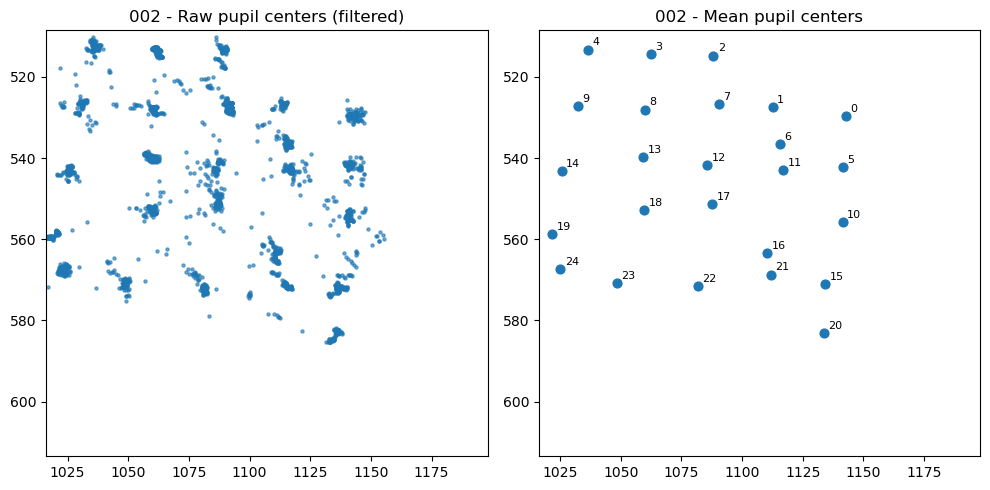

In [ ]:
def plot_raw_and_mean_pupils(subject_id: str):
    """Plot raw vs. mean pupil centers for one subject (filtered)."""

    # Build file paths
    subj_dir = data_dir / subject_id
    raw_csv = subj_dir / "pupil_coordinates.csv"
    mean_csv = subj_dir / "grid25" / "mean_pupil_coordinates.csv"
    failed_csv = PUPIL_DETECTION_DIR / "failed_pupil_detection.csv"

    # Load data
    df_raw = pd.read_csv(raw_csv)
    df_mean = pd.read_csv(mean_csv)

    # Use raw data range for consistent axis limits
    x_min, x_max = df_raw["px"].min(), df_raw["px"].max()
    y_min, y_max = df_raw["py"].min(), df_raw["py"].max()

    # Remove frames flagged as bad
    if failed_csv.exists():
        df_failed = pd.read_csv(failed_csv)

        # Keep only bad images for this subject
        subject_failed = df_failed[
            df_failed["image_path"].str.contains(f"/{subject_id}/frames/")
        ]

        # Extract filenames and filter raw data
        bad_filenames = subject_failed["image_path"].apply(lambda p: Path(p).name)
        df_raw = df_raw[~df_raw["image"].isin(bad_filenames)]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot raw pupil centers (filtered)
    axes[0].scatter(df_raw["px"], df_raw["py"], s=5, alpha=0.6)
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[0].invert_yaxis()
    axes[0].set_title(f"{subject_id} - Raw pupil centers (filtered)")

    # Plot mean pupil centers (one per target)
    axes[1].scatter(df_mean["px"], df_mean["py"], s=40)

    # Annotate each mean point with its index (target id)
    for i, row in df_mean.reset_index(drop=True).iterrows():
        axes[1].annotate(
            str(i),
            (row["px"], row["py"]),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=8
        )

    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    axes[1].invert_yaxis()
    axes[1].set_title(f"{subject_id} - Mean pupil centers")

    plt.tight_layout()
    plt.show()


# Example visualization
plot_raw_and_mean_pupils("002")